<a href="https://colab.research.google.com/github/emmagiometti/RemoteSensing_2026/blob/main/RSES_TP2_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RSES - Exercise 2

The first step is to load the libraries that will be needed for this exercise.

In [1]:
# Install required packages for geospatial analysis and interactive plotting.
# Use this line if you are running the notebook in an environment where these packages are not already installed (e.g., Google Colab).
!pip install -q rasterio rioxarray ipympl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 45.6 MB/s eta 0:00:00


In [2]:
#Import the necessary packages
import os  # Operating system interface
import rasterio  # For reading and writing raster datasets
import rasterio.plot  # For plotting raster data
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For plotting and visualization
import xarray as xr  # For working with multi-dimensional arrays
import rioxarray as rioxr  # For raster data with xarray
import ipywidgets as widgets  # For interactive widgets in Jupyter
from ipywidgets import interact  # For interactive controls

In [5]:
#Point to the directory where the data is stored (or comment this line and upload your files if you work in Google Colab)
#os.chdir("Remote Sensing/TP2 mapping and spatial requests-20261008/20150821")

### 1. Reading TIF files with the rasterio package

The image we have here is a Landsat 8 image with 11 bands, in a geotiff format.

The area of interest is the southern shore of Lake Geneva.

For the first band we have a georeferenced tiff. Let's open it and look at it:

In [6]:
# Load the GeoTIFF file as an xarray
B1 = xr.open_dataarray('20150821.B1.tif')
print('Shape of the loaded image: ',B1.shape)
B1 = B1.squeeze()  # Removes dimensions of size 1
print('Shape of the image after squeezing: ',B1.shape)


Shape of the loaded image:  (1, 802, 2016)
Shape of the image after squeezing:  (802, 2016)


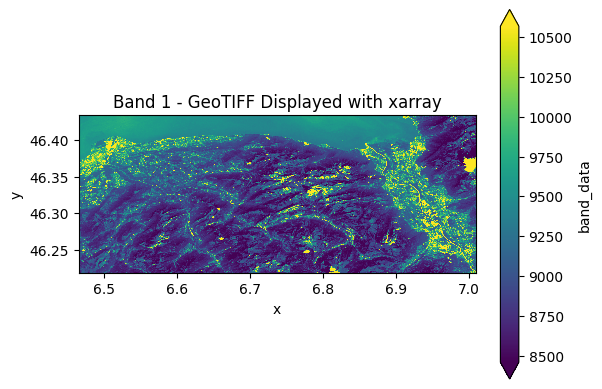

In [7]:
# Display the image using xarray's plot function
B1.plot.imshow(robust=True)  # robust=True applies contrast stretching based on the 2nd–98th percentile for better visualization
plt.title('Band 1 - GeoTIFF Displayed with xarray')
plt.axis('image')
plt.show()

Note that the axes labels are in latitude and longitude. This is because the image is a geotiff, which contains not only pixels values, but also georeferencing information.

### 2. Loading all bands and plotting RGB

Now let's load all 11 bands of our Landsat-8 image.

Keep in mind that Python indices start at 0! So band 1 will be the 0th entry of the list "bands"

We will switch from using the original rasterio package to the xarray package, a very powerful data package that also uses rasterio to read .tif files


In [8]:
# Create an empty list to store each band as a DataArray
bands = []

# Loop through band numbers 1 to 11 (inclusive) and each time load and add a new band to the list
for i in range(1, 12):

    # Open each band as a DataArray and place it in a temporary variable
    # The tif files have systematic names, with only the number that changes
    tmp=xr.open_dataarray(f'20150821.B{i}.tif')

    # Squeeze each band so that dimensions are in the correct order (try to comment this line and see what happens)
    tmp=tmp.squeeze()

    # Append the opened band to the list
    bands.append(tmp)

    # Check out the size of each band as it is loaded
    print(tmp.shape)


(802, 2016)
(802, 2016)
(802, 2016)
(802, 2016)
(802, 2016)
(802, 2016)
(802, 2016)
(1603, 4032)
(802, 2016)
(802, 2016)
(802, 2016)


You can see that band 8 has more pixels. It is the panchromatic band, which has a higher resolution. Can you try to show it separately?

In [9]:
# Here we print the first band (numbering starts with 0 in Python).
# Print only displays information about the image, it does not open a figure (this is done with imshow).
print('image properties')
print(bands[0])
print()

print('single value:')
single_value = bands[0].isel(y=0, x=0).item()
print(single_value)
print()
print()

print('small crop:')
small_crop = bands[0].isel(y=slice(0,10), x=slice(0,10))
print(small_crop.values)
print()
print()

print('entire image:')
print(bands[0].values)

image properties
<xarray.DataArray 'band_data' (y: 802, x: 2016)> Size: 6MB
[1616832 values with dtype=float32]
Coordinates:
  * y            (y) float64 6kB 46.43 46.43 46.43 46.43 ... 46.22 46.22 46.22
  * x            (x) float64 16kB 6.466 6.466 6.467 6.467 ... 7.009 7.009 7.009
    band         int64 8B 1
    spatial_ref  int64 8B ...
Attributes:
    AREA_OR_POINT:  Area

single value:
9584.0


small crop:
[[9584. 9584. 9629. 9622. 9622. 9598. 9597. 9597. 9603. 9608.]
 [9600. 9600. 9596. 9589. 9589. 9586. 9590. 9590. 9597. 9611.]
 [9556. 9556. 9567. 9591. 9591. 9595. 9599. 9599. 9605. 9593.]
 [9561. 9561. 9608. 9581. 9581. 9625. 9581. 9585. 9585. 9610.]
 [9563. 9563. 9593. 9592. 9592. 9594. 9599. 9600. 9600. 9589.]
 [9577. 9577. 9585. 9577. 9570. 9570. 9593. 9573. 9573. 9577.]
 [9580. 9576. 9576. 9581. 9556. 9556. 9573. 9557. 9557. 9576.]
 [9603. 9560. 9560. 9560. 9578. 9578. 9563. 9592. 9592. 9579.]
 [9565. 9559. 9559. 9573. 9570. 9570. 9563. 9570. 9570. 9579.]
 [9576. 9580. 9580

Let's make a RGB color composition with B2=>blue, B3=>green and B4=>red.

In [10]:
# Select bands for RGB composition:
Red = bands[3]   # Band 4 (red channel)
Green = bands[2] # Band 3 (green channel)
Blue = bands[1]  # Band 2 (blue channel)

# Combine (=concatenate) the selected bands into a single DataArray and transpose to (y, x, band) for plotting
RGB = xr.concat([Red, Green, Blue], dim = 'band').transpose('y', 'x', 'band')


In [11]:
# Display the shape of the RGB
RGB.shape


(802, 2016, 3)

Let's take a look at the RGB image

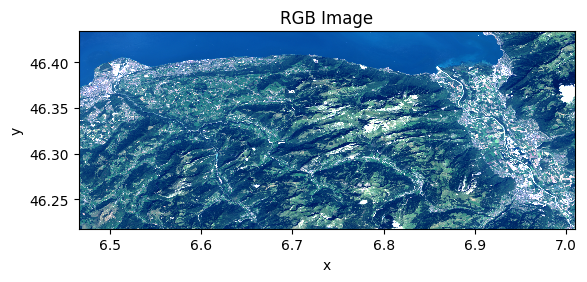

In [12]:
# Plot the RGB image using matplotlib and xarray
plt.figure()  # Create a new figure for the plot
RGB.plot.imshow(robust = True)  # Show the RGB image with contrast stretching for better visualization
plt.title('RGB Image')  # Add a title to the plot
plt.axis('image')
plt.show() # Render the figure on screen.


Repeat section 2 with different colors compositions, like you would play with the bands colors in QGIS. This can be done by changing B4, B3 and B2 to other bands.

You will see that band 8 (bands[7]) cannot be displayed: because it has a different resolution, it cannot be combined with other bands.


### 3. Band inspection and classification

Now that we can load and display our image, we will look at some bands values at specific locations.
The following piece of code lets you slide the latitude and longitude on the image and displays the Digital Numbers values (DNs) for all bands.

In [ ]:
def update_plot(lat, lon):

    # Create a Figure with two horizontal subplots: ax1 (image), ax2 (spectrum).
    f, (ax1, ax2) = plt.subplots(1,2, figsize = (15,6))

    # Display the RGB composite. `robust=True` uses the 2nd–98th percentile to set
    # color limits, which improves contrast in the presence of outliers.
    #RGB.plot.imshow(robust=True, ax=ax1)
    RGB.plot.imshow(ax=ax1, robust=True, add_colorbar=False)

    # Overlay the point of interest as a red cross ('rx') at (lon, lat).
    ax1.plot(lon, lat, 'rx', label='Point of interest') #'rx' means red cross, 'bo' would be a blue circle etc.
    ax1.legend()
    ax1.set_title('RGB image')
    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')

    # Sample each band at the selected (lon, lat) using nearest neighbor and extract a Python scalar.
    # Assumes each `band` is an xarray.DataArray with coordinates named x (lon) and y (lat).
    bandsval = [band.sel(x=lon, y=lat, method='nearest').item() for band in bands]
    bandsval[7] = np.nan #this is band 8!
    bandsval[8] = np.nan

    # Plot the spectral signature as points connected by lines.
    # np.arange(1, 12) yields [1, 2, ..., 11]; this implies there are 11 bands tot
    ax2.plot(np.arange(1, 12), bandsval, '.-')
    ax2.set_title('Spectral signature (without bands 8 and 9)')
    ax2.grid()
    ax2.set_xlabel('Band number')
    ax2.set_ylabel('Digital number (DN)')
    ax2.set_ylim(0,65536) # 16-bit image range
    plt.show()

# Interactive sliders for (lat, lon). If RGB.x / RGB.y are xarray objects, .min() / .max() return the min/max coordinates.
lat_slider = widgets.FloatSlider(value=46.4, min=RGB.y.min(), max=RGB.y.max(), step=0.01, description='Latitude:')
lon_slider = widgets.FloatSlider(value=6.9, min= RGB.x.min(), max=RGB.x.max(), step=0.01, description='Longitude:')

print(lat_slider)

interact(update_plot, lat=lat_slider, lon=lon_slider)
#update_plot(46.3, 6.9)  # Initial plot with default values

FloatSlider(value=46.4, description='Latitude:', max=46.43378228884545, min=46.21791712607153, step=0.01)


interactive(children=(FloatSlider(value=46.4, description='Latitude:', max=46.43378228884545, min=46.217917126…

<function __main__.update_plot(lat, lon)>

Slide to different locations on the image to observe the band values for various surfaces. You can also zoom in on specific locations of your image to see details better.

Based on these observations and the course content, let's identify one criterion that allows us to identify water: it seems that low near-infrared values (band 5) will be good for this. Let's isolate these pixels:

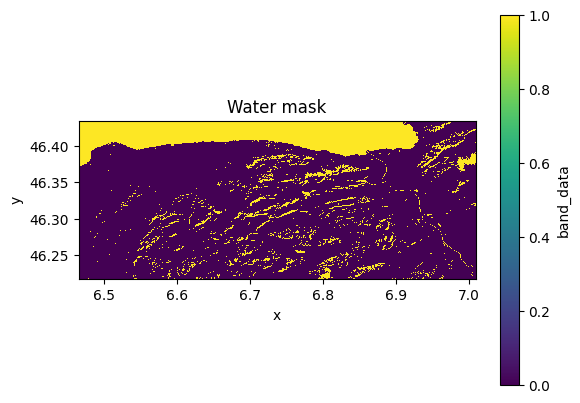

In [ ]:

# Create a boolean mask where pixels in band 5 (index 4) have values < 10,000.
# This is often used to identify water bodies in satellite imagery because water
# typically has low reflectance in the near-infrared band.
Water = bands[4] < 10000  # Returns True for water-like pixels, False otherwise.

# Start a new figure for plotting.
plt.figure()
plt.clf()  # Clear the current figure to avoid overlapping plots.

# Plot the water mask. If `Water` is an xarray.DataArray, .plot() uses its coords.
Water.plot.imshow()

# Add a title to the plot for clarity.
plt.title('Water mask')

# Display the figure.
plt.axis('image')
plt.show()


You can see that it isolates water bodies, but also places where all bands have a low value (especially areas in the shade).

So it is not the best test to identify water.

Let's try something different: we isolate all pixels where band 5 value is smaller than band 4 value:

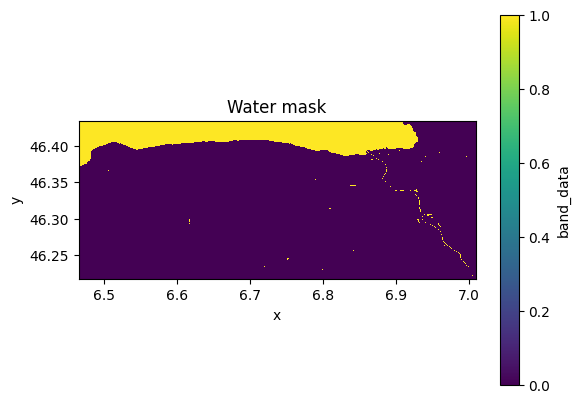

In [ ]:
# Create a boolean mask to identify water pixels.
# Logic: Water typically reflects less in the near-infrared (NIR) band than in the red band.
# So, if NIR < Red, the pixel is likely water.

Water = bands[4] < bands[3]
plt.figure()
plt.clf()
Water.plot.imshow()
plt.title('Water mask')
plt.axis('image')
plt.show()

Now that we have identified the water, we can divide it further into lake and rivers.

By observing the bands, we see that the rivers have higher values in the band 1 (coastal blue), because they are shallow.

So let's try to identify the rivers by defining them as the pixels that belong to the water, but have band 1 values above a limit of 1e4:

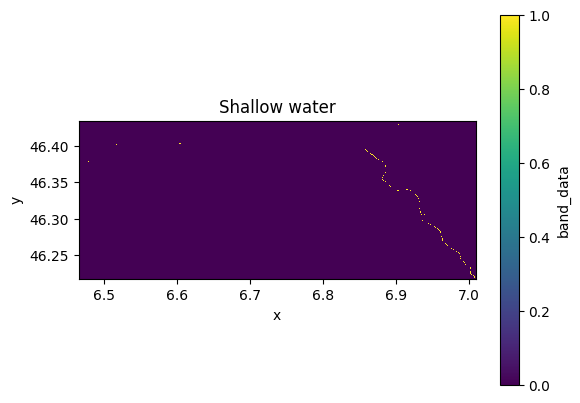

In [ ]:

# Create a boolean mask for shallow water.
# Logic:
# - `Water` is an existing mask where the boolean test (Water==1) = water pixels.
# - `bands[0] > 10000` checks if the pixel is bright in band 1.
#   Brightness in blue often indicates shallow water because the bottom reflects more light.
# - The `&` operator is a bitwise AND for arrays, used here as a logical AND:
#   both conditions must be True (pixel is water AND bright in blue band).

Shallow = (Water==1) & (bands[0] > 10000)

# Note the symbol & which is a boolean operator meaning "and":
# both tests have to be true.

plt.figure()
plt.clf()
Shallow.plot()
plt.title('Shallow water')
plt.axis('image')
plt.show()


We can continue the process. Let's isolate the lighter areas in the lake, corresponding to locations of higher sediment load or more loaded with plancton.

These are the lake pixels, excluding the river pixels, and with a band 3 value (green) higher than 0.75e4:

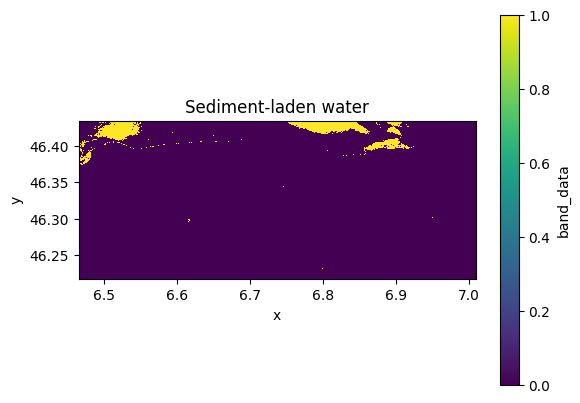

In [ ]:
# Identify sediment-laden water using band 3 values
# Create a boolean mask for sediment-laden water.
# Conditions:
# 1. Pixel is water (Water == 1).
# 2. Pixel is NOT shallow water (Shallow == 0).
# 3. Pixel is bright in band 3 (usually green band), meaning reflectance > 7500.
#    High green reflectance often indicates suspended sediments in water

Sediment = (Water == 1) & (Shallow == 0) & (bands[2] > 7500)
# All three conditions must be True for a pixel to be classified as sediment-laden water.

plt.figure()
plt.clf()
Sediment.plot()
plt.title('Sediment-laden water')
plt.axis('image')
plt.show()


Some part of the shallow coastline have also been included because there is more plancton near the coast.

### To complete yourself

In [ ]:
# Calculate NDWI (Normalised difference Water index)
B3 = bands[2]
B5 = bands[4]

# Here canculate NDWI
NDWI=...

plt.figure()
plt.clf()
NDWI.plot()
plt.axis('image')
plt.show()


AttributeError: 'ellipsis' object has no attribute 'plot'

<Figure size 640x480 with 0 Axes>

In [ ]:
# Display a figure showing all pixels where NDWI is larger than 0.1


In [ ]:


# Calculate NDVI, display it, and display a figure of NDVI > 0.2
